## Snippet for creating overlays (ground truth compared to obtained detection boxes on one mosaic)

In [30]:
from src.utils.io import load_np_image, save_np_image
from src.eval.metrics import load_boxes
from src.utils.vis import draw_overlay_boxes

mosaic = load_np_image("data/interim/mosaic.jpg")
gt  = load_boxes("data/processed/gt_detections.json")
pr  = load_boxes("data/processed/p2_detections.json")

overlay = draw_overlay_boxes(mosaic, gt, pr)
save_np_image(overlay, "data/processed/overlay_p2.jpg")

## Snippet for filtering projections based on the perspective of your ground truth image.

cwd: C:\Users\Aleksa\Documents\CS root\FRI\3. godina 2. semestar\Diplomska\uav-object-counting-bsc-cs
Detections: total=39, kept_in_ROI=37, removed=2
Saved filtered detections → data\processed\pX_detections_roi.json


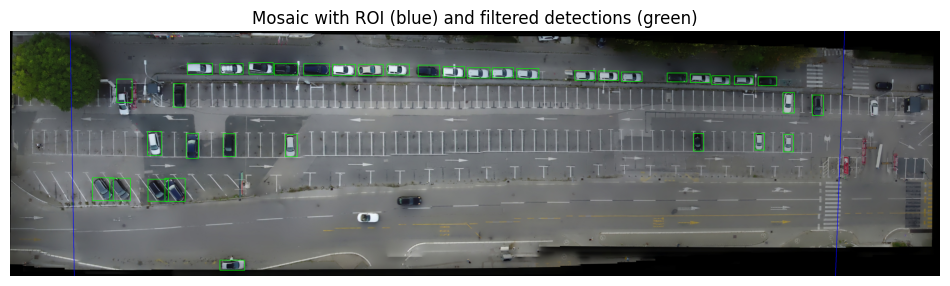

[{'frame_idx': 0,
  'x1_b': 1276.2430419921875,
  'y1_b': 1348.3101806640625,
  'x2_b': 1451.13330078125,
  'y2_b': 1547.134033203125,
  'id': 1,
  'x1': 683.0895294283758,
  'y1': 732.9109016237035,
  'x2': 784.6066976570959,
  'y2': 841.2442661532948,
  'conf': 0.9118254035711288,
  'support_members': 12,
  'support_frames': 12,
  'tex_std': 38.687931325058635,
  'tex_edge_frac': 0.13781223083548666},
 {'frame_idx': 1,
  'x1_b': 1272.3472900390625,
  'y1_b': 917.7656860351562,
  'x2_b': 1393.2835693359375,
  'y2_b': 1130.413818359375,
  'id': 21,
  'x1': 681.9185978140239,
  'y1': 496.6424587459593,
  'x2': 751.4140091656654,
  'y2': 614.8762737261483,
  'conf': 0.9081512888272604,
  'support_members': 12,
  'support_frames': 12,
  'tex_std': 64.88692544843511,
  'tex_edge_frac': 0.10851674641148325},
 {'frame_idx': 6,
  'x1_b': 406.083740234375,
  'y1_b': 1326.646240234375,
  'x2_b': 598.8597412109375,
  'y2_b': 1536.4034423828125,
  'id': 129,
  'x1': 408.9624840083764,
  'y1': 725

In [21]:
# --- ROI filter from GT coverage (paste this in one Jupyter cell) ---
from pathlib import Path
import json, numpy as np, cv2, matplotlib.pyplot as plt

# ==== USER INPUTS ====
gt_image_path = Path("data") / "raw" / "ground_truth.jpg"
mosaic_path   = Path("data") / "interim" / "mosaic.jpg"
detections_json = Path("data/processed/p2_detections.json")  # mosaic detections JSON (x1,y1,x2,y2[,conf])
save_filtered_to = Path("data/processed/pX_detections_roi.json")  # optional output; set to None to skip
# =====================

def load_image(p: Path):
    img = cv2.imread(str(p))
    if img is None:
        raise FileNotFoundError(p)
    return img

def try_compute_homography(gt_img, mosaic_img):
    """Try project helper first; fallback to ORB+RANSAC."""
    try:
        from src.utils.geometry import compute_homography  # your function
        H = compute_homography(gt_img, mosaic_img, cfg={})
        if H is not None and np.asarray(H).shape == (3,3):
            return np.asarray(H, dtype=np.float64)
    except Exception:
        pass

    # Fallback: ORB + BF + RANSAC
    orb = cv2.ORB_create(4000)
    kp1, des1 = orb.detectAndCompute(gt_img, None)
    kp2, des2 = orb.detectAndCompute(mosaic_img, None)
    if des1 is None or des2 is None:
        raise RuntimeError("ORB could not compute descriptors for one of the images.")
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m,n in matches if m.distance < 0.75*n.distance]
    if len(good) < 12:
        raise RuntimeError(f"Not enough good matches for homography (got {len(good)}).")
    src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 3.0)
    if H is None:
        raise RuntimeError("cv2.findHomography failed.")
    return H

def gt_rect_to_roi_polygon(gt_img, H):
    """Warp GT image rectangle into mosaic coords → 4-pt polygon."""
    h, w = gt_img.shape[:2]
    rect = np.array([[[0,0]], [[w,0]], [[w,h]], [[0,h]]], dtype=np.float32)
    wpts = cv2.perspectiveTransform(rect, H).reshape(-1,2)
    return [(float(x), float(y)) for (x,y) in wpts]

def center_in_poly(box, poly):
    """Keep box if its center is inside/on ROI polygon."""
    cnt = np.array(poly, dtype=np.float32).reshape(-1,1,2)
    cx = 0.5*(float(box["x1"])+float(box["x2"]))
    cy = 0.5*(float(box["y1"])+float(box["y2"]))
    return cv2.pointPolygonTest(cnt, (cx, cy), False) >= 0

def load_detections(p: Path):
    with p.open("r", encoding="utf-8") as f:
        return json.load(f)

def draw_boxes(img, dets, color=(0,255,0), thickness=2):
    out = img.copy()
    for d in dets:
        x1,y1,x2,y2 = int(d["x1"]), int(d["y1"]), int(d["x2"]), int(d["y2"])
        cv2.rectangle(out, (x1,y1), (x2,y2), color, thickness)
    return out

def draw_polygon(img, poly, color=(255,0,0), thickness=2):
    pts = np.array(poly, dtype=np.int32).reshape(-1,1,2)
    cv2.polylines(img, [pts], True, color, thickness)
    return img

# ---- run ----
print("cwd:", Path.cwd())
mosaic_img = load_image(mosaic_path)
gt_img     = load_image(gt_image_path)
H = try_compute_homography(gt_img, mosaic_img)
roi_poly = gt_rect_to_roi_polygon(gt_img, H)

# Load mosaic detections and filter to ROI
dets_all = load_detections(detections_json)
dets_in  = [d for d in dets_all if center_in_poly(d, roi_poly)]
print(f"Detections: total={len(dets_all)}, kept_in_ROI={len(dets_in)}, removed={len(dets_all)-len(dets_in)}")

# Save filtered JSON (optional)
if save_filtered_to is not None:
    save_filtered_to.parent.mkdir(parents=True, exist_ok=True)
    with save_filtered_to.open("w", encoding="utf-8") as f:
        json.dump(dets_in, f, indent=2)
    print("Saved filtered detections →", save_filtered_to)

# Sanity visualization (ROI outline + kept detections)
vis = draw_polygon(mosaic_img, roi_poly, color=(255,0,0), thickness=2)  # blue-ish line (BGR)
vis = draw_boxes(vis, dets_in, color=(0,255,0), thickness=2)            # green kept
# (optional) draw discarded in light-red:
# dets_out = [d for d in dets_all if not center_in_poly(d, roi_poly)]
# vis = draw_boxes(vis, dets_out, color=(0,0,200), thickness=1)

# Show with matplotlib (convert BGR→RGB)
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Mosaic with ROI (blue) and filtered detections (green)")
plt.axis("off")
plt.show()

# Return filtered detections as last expression (handy in notebooks)
dets_in
